# Notebook: Guard coverage experiment
# Purpose: Empirically validate that ConformalRegionOracle coverage ~ 1 - alpha


In [12]:
## 1) Import libraries and helpers

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil
from sklearn.datasets import load_wine, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Local imports from the package
from calibrated_explanations.guards.regions import ConformalRegionOracle
from calibrated_explanations import CalibratedExplainer

# Helpers
RNG_SEED = 42
np.random.seed(RNG_SEED)
# set OMP_NUM_THREADS for native libraries (best to place before imports that use OpenMP/BLAS)
os.environ["OMP_NUM_THREADS"] = "2"
os.putenv("OMP_NUM_THREADS", "2")

def quantile_index(n, alpha):
    # Following the index approach used by ConformalRegionOracle.fit
    idx = int(ceil((1.0 - alpha) * n))
    idx = min(idx, max(0, n - 1))
    return idx


def compute_empirical_coverage(guard, X_test, threshold):
    # Use the guard's nonconformity scoring to evaluate test coverage
    s_test = guard._compute_nonconformity_scores(X_test)
    return float(np.mean(s_test <= threshold)), s_test


In [13]:
## 2) Prepare dataset and splits

# Choose dataset: wine is small and balanced; breast_cancer is also fine.
data = load_breast_cancer()
X = data.data.astype(float)
y = (data.target == 0).astype(int)  # make a binary task for simplicity

# Create splits: proper training (for clustering/fit), calibration, and held-out test
# We'll use a fairly large test set to estimate coverage reliably.
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=RNG_SEED)
X_proper, X_cal, y_proper, y_cal = train_test_split(X_temp, y_temp, test_size=0.3333, random_state=RNG_SEED)

print("Sizes: proper=", X_proper.shape, "cal=", X_cal.shape, "test=", X_test.shape)


Sizes: proper= (303, 30) cal= (152, 30) test= (114, 30)


In [14]:
## 3) Train a classifier and build CalibratedExplainer (with and without guard)

clf = RandomForestClassifier(n_estimators=100, random_state=RNG_SEED)
clf.fit(X_proper, y_proper)

# Build an explainer with guard params (this also demonstrates the typical path)
# We create a small wrapper to show that CalibratedExplainer can accept guard_params.
explainer_with_guard = CalibratedExplainer(clf, X_cal, y_cal, feature_names=[f"f{i}" for i in range(X.shape[1])], guard_params={"alpha":0.1, "n_clusters":5, "random_state":RNG_SEED})
explainer_without_guard = CalibratedExplainer(clf, X_cal, y_cal, feature_names=[f"f{i}" for i in range(X.shape[1])], guard=None)

print("Explainer guard fitted?", getattr(explainer_with_guard.guard, "_fitted", None))


c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Explainer guard fitted? True


In [21]:
## 4) Fit ConformalRegionOracle + compute calibration quantile thresholds for different alphas

alphas = [0.01, 0.05, 0.1, 0.2]
results = []

for alpha in alphas:
    print(f"\n--- alpha={alpha} ---")
    # instantiate and fit guard directly (using proper set as training set and explicit calibration set)
    g = ConformalRegionOracle(alpha=alpha, n_clusters=5, random_state=RNG_SEED)
    # pass the calibrated explainer as the interval_learner (required)
    g.fit(X_proper, y_proper, interval_learner=explainer_with_guard, x_cal=X_cal, y_cal=y_cal)

    # calibration scores
    s_cal = g._cal_scores if getattr(g, "_cal_scores", None) is not None else g._compute_nonconformity_scores(X_cal)
    n_cal = len(s_cal)
    q_idx = quantile_index(n_cal, alpha)
    s_cal_sorted = np.sort(s_cal)
    q_threshold = float(s_cal_sorted[q_idx])

    print(f"n_cal={n_cal}, quantile_idx={q_idx}, threshold={q_threshold:.6f}")
    results.append({"alpha": alpha, "n_cal": n_cal, "quantile_idx": q_idx, "threshold": q_threshold, "guard": g})

# Convert results to DataFrame for convenient reporting
res_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'guard'} for r in results])
res_df



--- alpha=0.01 ---


c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


n_cal=152, quantile_idx=151, threshold=23380.483652

--- alpha=0.05 ---


c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


n_cal=152, quantile_idx=145, threshold=24.923554

--- alpha=0.1 ---


c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


n_cal=152, quantile_idx=137, threshold=16.969098

--- alpha=0.2 ---


c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


n_cal=152, quantile_idx=122, threshold=10.895723


,alpha,n_cal,quantile_idx,threshold
0,0.01,152,151,23380.483652
1,0.05,152,145,24.923554
2,0.10,152,137,16.969098
3,0.20,152,122,10.895723


In [22]:
## 6) Monte Carlo runs across multiple random seeds (aggregate coverage)

# Number of Monte Carlo runs; reduce for quick tests, increase for final evaluation
n_runs = 100
seeds = list(range(100, 100 + n_runs))
alpha_list = [0.01, 0.05, 0.1, 0.2, 0.5]

mc_rows = []
for seed in seeds:
    # Resample splits to simulate variability
    X_tmp, X_test_mc, y_tmp, y_test_mc = train_test_split(X, y, test_size=0.2, random_state=seed)
    X_proper_mc, X_cal_mc, y_proper_mc, y_cal_mc = train_test_split(X_tmp, y_tmp, test_size=0.3333, random_state=seed)

    for alpha in alpha_list:
        g = ConformalRegionOracle(alpha=alpha, n_clusters=5, random_state=seed)
        # use the calibrated explainer for interval predictions
        g.fit(X_proper_mc, y_proper_mc, interval_learner=explainer_with_guard, x_cal=X_cal_mc, y_cal=y_cal_mc)

        s_cal = g._cal_scores
        q_idx = quantile_index(len(s_cal), alpha)
        q = float(np.sort(s_cal)[q_idx])

        cov, _ = compute_empirical_coverage(g, X_test_mc, q)
        mc_rows.append({"seed": seed, "alpha": alpha, "theoretical": 1 - alpha, "empirical": cov})

mc_df = pd.DataFrame(mc_rows)
summary = mc_df.groupby('alpha').empirical.agg(['mean', 'std', lambda x: np.percentile(x, 2.5), lambda x: np.percentile(x, 97.5)])
summary.columns = ['mean', 'std', 'ci_lower', 'ci_upper']
summary


c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: 

,mean,std,ci_lower,ci_upper
alpha,,,,
0.01,0.994211,0.009513,0.969079,1.000000
0.05,0.957018,0.023901,0.907675,1.000000
0.10,0.899474,0.036529,0.833333,0.964912
0.20,0.799737,0.051468,0.701754,0.899342
0.50,0.502456,0.057258,0.403509,0.596491


Saved plot to guard_coverage_summary.png


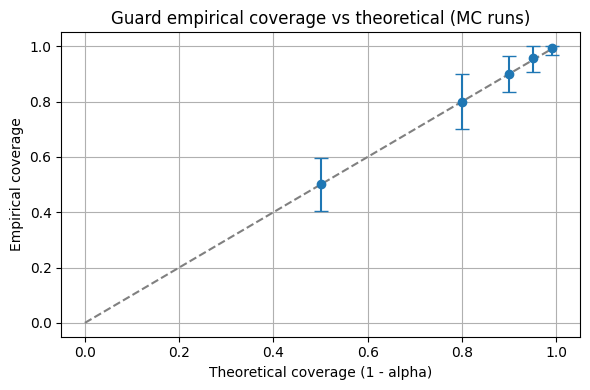

Saved MC results to guard_coverage_results.csv


In [23]:
## 7) Plot coverage vs theoretical (with CI)

import matplotlib.pyplot as plt

plot_df = summary.reset_index()
plot_df['target'] = 1 - plot_df['alpha']

plt.figure(figsize=(6, 4))
plt.errorbar(plot_df['target'], plot_df['mean'], yerr=[plot_df['mean'] - plot_df['ci_lower'], plot_df['ci_upper'] - plot_df['mean']], fmt='o', capsize=5)
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('Theoretical coverage (1 - alpha)')
plt.ylabel('Empirical coverage')
plt.title('Guard empirical coverage vs theoretical (MC runs)')
plt.grid(True)
plt.tight_layout()

out_png = 'guard_coverage_summary.png'
plt.savefig(out_png)
print('Saved plot to', out_png)
plt.show()

# Save aggregated CSV
out_csv = 'guard_coverage_results.csv'
mc_df.to_csv(out_csv, index=False)
print('Saved MC results to', out_csv)


In [ ]:
## 11) Cluster-size sensitivity analysis

# Test how the number of clusters affects empirical coverage.
cluster_sizes = [1, 3, 10, 25]
alpha_list = [0.01, 0.05, 0.1, 0.2]

n_runs_cs = 100  # Monte Carlo runs per cluster size (reduce if you want faster)
seeds_cs = list(range(200, 200 + n_runs_cs))

cs_rows = []
for n_clusters in cluster_sizes:
    print(f"\n=== n_clusters={n_clusters} ===")
    for seed in seeds_cs:
        # Resample splits
        X_tmp, X_test_cs, y_tmp, y_test_cs = train_test_split(X, y, test_size=0.2, random_state=seed)
        X_proper_cs, X_cal_cs, y_proper_cs, y_cal_cs = train_test_split(X_tmp, y_tmp, test_size=0.3333, random_state=seed)

        for alpha in alpha_list:
            g = ConformalRegionOracle(alpha=alpha, n_clusters=n_clusters, random_state=seed)
            # pass the explainer providing interval predictions
            g.fit(X_proper_cs, y_proper_cs, interval_learner=explainer_with_guard, x_cal=X_cal_cs, y_cal=y_cal_cs)

            s_cal = g._cal_scores
            q_idx = quantile_index(len(s_cal), alpha)
            q = float(np.sort(s_cal)[q_idx])

            cov, _ = compute_empirical_coverage(g, X_test_cs, q)
            cs_rows.append({
                'seed': seed,
                'n_clusters': n_clusters,
                'alpha': alpha,
                'theoretical': 1 - alpha,
                'empirical': cov,
            })

cs_df = pd.DataFrame(cs_rows)

# Aggregate: mean empirical per alpha and cluster size
agg = cs_df.groupby(['n_clusters', 'alpha']).empirical.agg(['mean', 'std']).reset_index()
print(agg.head())



=== n_clusters=1 ===


c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: 


=== n_clusters=3 ===


c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: 


=== n_clusters=10 ===


c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: 


=== n_clusters=25 ===


c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: 

C:\Users\loftuw\CUDATemp\ipykernel_67500\3801406772.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10')


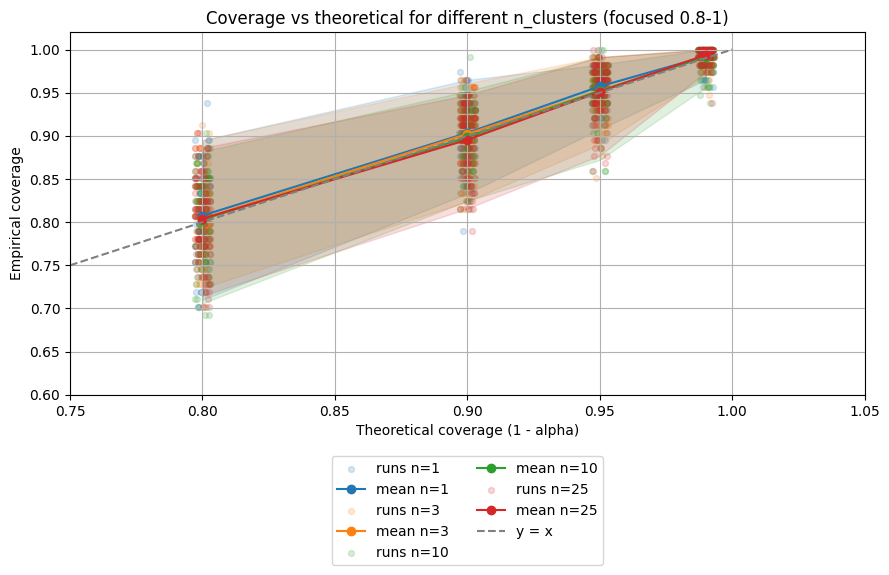

Saved cluster sensitivity CSV to guard_cluster_sensitivity.csv


In [ ]:
# Plot: for each cluster size, empirical coverage vs theoretical (1-alpha)
# Show per-run spread as scatter, mean line, and 95% empirical CI; focus x-axis on [0.8, 1.0]
import numpy as np

# Prepare data with target = 1 - alpha
plot_groups = cs_df.copy()
plot_groups['target'] = 1 - plot_groups['alpha']

# Compute group summary and empirical percentiles for CI
grp = plot_groups.groupby(['n_clusters', 'alpha'])['empirical']
summary = grp.agg(['mean', 'std', 'count']).reset_index()
ci_lower = grp.quantile(0.025).reset_index(name='ci_lower')
ci_upper = grp.quantile(0.975).reset_index(name='ci_upper')
summary = summary.merge(ci_lower, on=['n_clusters', 'alpha']).merge(ci_upper, on=['n_clusters', 'alpha'])
summary['target'] = 1 - summary['alpha']

# Focus on target >= 0.8 (i.e., 1 - alpha in [0.8, 1.0])
summary_f = summary[summary['target'] >= 0.8]

plt.figure(figsize=(9, 6))
colors = plt.cm.get_cmap('tab10')
for i, n_clusters in enumerate(cluster_sizes):
    sub = summary_f[summary_f['n_clusters'] == n_clusters].sort_values('alpha')
    if sub.empty:
        continue

    # plot per-run scatter for these cluster size (jitter x for visibility)
    runs = plot_groups[(plot_groups['n_clusters'] == n_clusters) & (plot_groups['target'] >= 0.8)]
    if len(runs) > 0:
        jitter = (np.random.RandomState(100 + i).rand(len(runs)) - 0.5) * 0.006
        plt.scatter(1 - runs['alpha'] + jitter, runs['empirical'], s=18, alpha=0.18, color=colors(i), label=f'runs n={n_clusters}')

    # plot mean line and fill CI
    plt.plot(sub['target'], sub['mean'], marker='o', color=colors(i), label=f'mean n={n_clusters}')
    plt.fill_between(sub['target'], sub['ci_lower'], sub['ci_upper'], color=colors(i), alpha=0.15)

# Diagonal and formatting
plt.plot([0.75, 1.0], [0.75, 1.0], '--', color='gray', label='y = x')
plt.xlim(0.75, 1.05)
plt.ylim(0.6, 1.02)
plt.xlabel('Theoretical coverage (1 - alpha)')
plt.ylabel('Empirical coverage')
plt.title('Coverage vs theoretical for different n_clusters (focused 0.8-1)')
plt.legend(ncol=2, bbox_to_anchor=(0.5, -0.15), loc='upper center')
plt.grid(True)
plt.tight_layout()
plt.show()

# Save cluster sensitivity results (already saved earlier) but keep for convenience
cs_out = 'guard_cluster_sensitivity.csv'
cs_df.to_csv(cs_out, index=False)
print('Saved cluster sensitivity CSV to', cs_out)


In [ ]:
# NEW CELL: compact run_width_sensitivity function
# (updated _extract_interval to unwrap object arrays of size 1)
def make_perturbations(x0, n=200, scale=0.1, rng=None):
    if rng is None:
        rng = np.random.RandomState(0)
    d = x0.shape[0]
    noise = rng.normal(scale=scale, size=(n, d))
    return x0.reshape(1, -1) + noise

def moving_average_sorted(x_vals, y_vals, window=5):
    order = np.argsort(x_vals)
    xs = x_vals[order]
    ys = y_vals[order]
    if len(ys) < window:
        return xs, ys
    kernel = np.ones(window) / window
    ys_smooth = np.convolve(ys, kernel, mode='same')
    return xs, ys_smooth

def _extract_interval(pred):
    import numpy as _np
    # handle numpy object arrays that wrap a tuple/list (shape (1,) with object dtype)
    if isinstance(pred, _np.ndarray) and pred.dtype == object and pred.size == 1:
        return _extract_interval(pred.item(0))
    pred_arr = _np.asarray(pred)
    if pred_arr.ndim == 2 and pred_arr.shape[1] >= 2:
        return float(pred_arr[0, 0]), float(pred_arr[0, 1])
    if pred_arr.ndim == 1 and pred_arr.size >= 2:
        return float(pred_arr[0]), float(pred_arr[1])
    if isinstance(pred, (list, tuple)) and len(pred) > 0:
        first = pred[0]
        if isinstance(first, (list, tuple, _np.ndarray)) and len(first) >= 2:
            return float(first[0]), float(first[1])
    if isinstance(pred, tuple) and len(pred) == 2:
        low, high = pred
        low_a = _np.asarray(low).ravel()
        high_a = _np.asarray(high).ravel()
        if low_a.size > 0 and high_a.size > 0:
            return float(low_a[0]), float(high_a[0])
    if isinstance(pred, dict):
        low = None
        high = None
        for lkey in ('lower', 'low', 'lo'):
            if lkey in pred:
                low = pred[lkey]
                break
        for hkey in ('upper', 'high', 'hi'):
            if hkey in pred:
                high = pred[hkey]
                break
        if low is not None and high is not None:
            low_a = _np.asarray(low).ravel()
            high_a = _np.asarray(high).ravel()
            if low_a.size > 0 and high_a.size > 0:
                return float(low_a[0]), float(high_a[0])
    raise RuntimeError(f'Could not parse interval from interval_learner.predict: got type={type(pred)}')

def run_width_sensitivity(explainer, X_proper, X_cal, y_cal, X_test, test_points_idx=None,
                          alphas=[0.01,0.05,0.1,0.2], n_points=20, n_perturbs=300, bins=10, n_buckets=5, seed=42):
    import matplotlib.pyplot as plt
    rng = np.random.RandomState(seed)
    if test_points_idx is None:
        sel_idx = rng.choice(len(X_test), size=min(n_points, len(X_test)), replace=False)
    else:
        sel_idx = test_points_idx
    test_points = X_test[sel_idx]
    results_rows = []
    for alpha in alphas:
        print(f'\\nRunning alpha={alpha}')
        g = ConformalRegionOracle(alpha=alpha, n_clusters=5, random_state=seed)
        g.fit(X_proper, None, interval_learner=explainer, x_cal=X_cal, y_cal=y_cal)
        for i, x0 in enumerate(test_points):
            scale = max(0.05, np.std(X_proper, axis=0).mean() * 0.15)
            perturbs = make_perturbations(x0, n=n_perturbs, scale=scale, rng=np.random.RandomState(seed + i))
            interval = explainer.predict(x0.reshape(1, -1))
            try:
                lower, upper = _extract_interval(interval)
            except Exception as exc:
                raise RuntimeError(f'Could not get interval from interval_learner: {exc}')
            width = float(upper - lower)
            cal_pred = (0.0, (lower, upper))
            accepts = g.accept_batch(perturbs, calibrated_predictions=[cal_pred] * len(perturbs))
            acc_rate = float(np.mean(accepts))
            results_rows.append({'alpha': alpha, 'point_idx': int(i), 'width': width, 'accept_rate': acc_rate})
    df_all = pd.DataFrame(results_rows)
    # Save and return
    df_all.to_csv('guard_width_acceptance_run.csv', index=False)
    print('Saved guard_width_acceptance_run.csv')
    return df_all

# Run with defaults and store to variable
width_df = run_width_sensitivity(explainer_with_guard, X_proper, X_cal, y_cal, X_test, n_points=20, n_perturbs=300)
print(width_df.groupby('alpha').width.describe())

\nRunning alpha=0.01


c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


RuntimeError: Could not get interval from interval_learner: Could not parse interval from interval_learner.predict: got type=<class 'numpy.ndarray'>